# MaBoSS quantitative tests of TabularQual round-trip for models from Biodivine 

In [ ]:
import os
import shutil
import maboss
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
os.environ["MallocStackLogging"] = "NO"


from tabularqual.convert_spreadsheet_to_sbml import convert_spreadsheet_to_sbml
from tabularqual.convert_sbml_to_spreadsheet import convert_sbml_to_spreadsheet

biodivine_model_dir = './biodivine/'

ipylab module is not installed, menus and toolbar are disabled.


### Extract source SBML-qual model

In [3]:
# Extract source files from BioDivine

source_directory = biodivine_model_dir + "sources"
destination_directory = "biodivine_models"

os.makedirs(destination_directory, exist_ok=True)
for subfolder in os.listdir(source_directory):
    subfolder_path = os.path.join(source_directory, subfolder)
    if os.path.isdir(subfolder_path):
        sbml_file_path = os.path.join(subfolder_path, "source.sbml")
        if os.path.isfile(sbml_file_path):
            target_path = os.path.join(destination_directory, f"{subfolder}_source.sbml")
            shutil.copy(sbml_file_path, target_path)

### Performing round trip

In [3]:
os.makedirs(os.path.join("biodivine_models", "tmp"), exist_ok=True)
for model in tqdm(os.listdir("biodivine_models")):
    sbml_spreadsheet_errors = []
    spreadsheet_sbml_errors = []
    if model.endswith(".sbml") and not model.endswith("_new.sbml"):
        sbml_file = os.path.join("biodivine_models", model)
        spreadsheet_file = os.path.join("biodivine_models", "tmp", ".".join(model.split(".")[:-1]) + ".xlsx")
        new_sbml_file = os.path.join("biodivine_models", "tmp", ".".join(model.split(".")[:-1]) + "_new.sbml")
        try:
            convert_sbml_to_spreadsheet(
                sbml_file,
                spreadsheet_file,
                template_path=None,  # No template to skip README/Appendix
                rule_format="operators",
                validate=False, # no validation
                print_messages=False, # no messages,
                use_name=False
            )
        except:
            print(f"error: {model}")
            sbml_spreadsheet_errors.append(model)
            continue

        try:
            convert_spreadsheet_to_sbml(
                spreadsheet_file,
                new_sbml_file,
                interactions_anno=False, # no existing interaction annotations
                transitions_anno=True,
                validate=False, # no validation
                print_messages=False, # no messages,
                use_name=False
            )
        except :
            spreadsheet_sbml_errors.append(model)
        

  0%|          | 0/206 [00:00<?, ?it/s]

### Listing SBML models which could be loaded by TabularQual

In [4]:
sbml_spreadsheet_errors

[]

In [5]:
sbml_spreadsheet_errors

[]

### Listing SBML models which couldn't be written back to SBML

In [6]:
spreadsheet_sbml_errors

[]

### Simulating both original models and models generated by the round trip

In [ ]:
cant_load_original = []
cant_load = []
cant_simulate = []
results = {}

for model in tqdm(os.listdir("biodivine_models")):
    if model.endswith(".sbml") and not model.endswith("_new.sbml"):
        sbml_file = os.path.join("biodivine_models", model)
        spreadsheet_file = os.path.join("biodivine_models", "tmp", ".".join(model.split(".")[:-1]) + ".xlsx")
        new_sbml_file = os.path.join("biodivine_models", "tmp", ".".join(model.split(".")[:-1]) + "_new.sbml")
        if os.path.exists(new_sbml_file):
            print(new_sbml_file)
            try:
                m = maboss.loadSBML(sbml_file)
            except Exception as e:
                print(f"error: {e}")
                cant_load_original.append(model)
                continue
                
            try:
                m_new = maboss.loadSBML(new_sbml_file)
            except Exception as e:
                print(f"error: {e}")
                cant_load.append(model)
                continue
            
            m.update_parameters(max_time=100, time_tick=10, sample_count=10000, thread_count=16)
            for node in m.network:
                m.network.set_istate(node, [0.5, 0.5])
            r = m.run(cmaboss=True)
            
            try:
                m_new.update_parameters(max_time=100, time_tick=10, sample_count=10000, thread_count=16)
                for node in m_new.network:
                    m_new.network.set_istate(node, [0.5, 0.5])
                r_new = m_new.run(cmaboss=True)
            except Exception as e:
                print(f"error: {e}")
                cant_simulate.append(model)
                continue

            results[model] = (r.get_nodes_probtraj(), r_new.get_nodes_probtraj())

In [9]:
model = "004_ERBB-RECEPTOR-SIGNALING_source.sbml"
model = "039_HIV-1-INTERACTIONS-WITH-T-CELL-SIGNALING_source.sbml"
sbml_file = os.path.join("biodivine_models", model)
spreadsheet_file = os.path.join("biodivine_models", "tmp", ".".join(model.split(".")[:-1]) + ".xlsx")
new_sbml_file = os.path.join("biodivine_models", "tmp", ".".join(model.split(".")[:-1]) + "_new.sbml")
print(new_sbml_file)
m = maboss.loadSBML(sbml_file)
m_new = maboss.loadSBML(new_sbml_file)

biodivine_models/tmp/039_HIV-1-INTERACTIONS-WITH-T-CELL-SIGNALING_source_new.sbml


In [ ]:
len(m.network)

138

In [11]:
m.update_parameters(max_time=100, time_tick=10, sample_count=100000, thread_count=16)
for node in m.network:
    m.network.set_istate(node, [0.5, 0.5])
r = m.run(cmaboss=True)
r.get_nodes_probtraj()

,S_1,S_10,S_100,S_101,S_102,S_103,S_104,S_105,S_106,S_107,S_108,S_109,S_11,S_110,S_111,S_112,S_113,S_114,S_115,S_116,S_117,S_118,S_119,S_12,S_120,S_121,S_122,S_123,S_124,S_125,S_126,S_127,S_128,S_129,S_13,S_130,S_131,S_132,S_133,S_134,S_135,S_136,S_137,S_138,S_14,S_15,S_16,S_17,S_18,S_19,S_2,S_20,S_21,S_22,S_23,S_24,S_25,S_26,S_27,S_28,S_29,S_3,S_30,S_31,S_32,S_33,S_34,S_35,S_36,S_37,S_38,S_39,S_4,S_40,S_41,S_42,S_43,S_44,S_45,S_46,S_47,S_48,S_49,S_5,S_50,S_51,S_52,S_53,S_54,S_55,S_56,S_57,S_58,S_59,S_6,S_60,S_61,S_62,S_63,S_64,S_65,S_66,S_67,S_68,S_69,S_7,S_70,S_71,S_72,S_73,S_74,S_75,S_76,S_77,S_78,S_79,S_8,S_80,S_81,S_82,S_83,S_84,S_85,S_86,S_87,S_88,S_89,S_9,S_90,S_91,S_92,S_93,S_94,S_95,S_96,S_97,S_98,S_99
0.0,0.900146,0.805871,0.934067,0.789441,0.929129,0.589061,0.824577,0.935703,0.942358,0.50003,0.49997,0.943922,0.625163,0.736404,0.891727,0.499893,0.921140,0.94876,0.919681,0.853931,0.772828,0.909574,0.874571,0.879496,0.941640,0.908651,0.917706,0.925025,0.936453,0.49998,0.941812,0.341727,0.917378,0.107833,0.903312,0.589064,0.883709,0.818665,0.499935,0.921010,0.327966,0.943911,0.884625,0.477226,0.049661,0.854741,0.50005,0.49997,0.5,0.332048,0.176499,0.922577,0.686023,0.49997,0.867738,0.942387,0.906730,0.923433,0.854646,0.780560,0.499887,0.267926,0.858890,0.942298,0.829304,0.947819,0.924909,0.860637,0.393098,0.876815,0.349586,0.917736,0.899708,0.50003,0.927001,0.685498,0.907775,0.901007,0.906869,0.109626,0.333056,0.499819,0.49998,0.928829,0.860735,0.942744,0.853772,0.650192,0.931036,0.838482,0.708679,0.939052,0.906150,0.924968,0.942479,0.854715,0.909177,0.428439,0.926679,0.608894,0.936129,0.887769,0.332152,0.858657,0.943536,0.938258,0.343715,0.867944,0.49999,0.49995,0.076912,0.364902,0.904361,0.946734,0.50001,0.878008,0.881114,0.854569,0.49997,0.853441,0.935355,0.669385,0.50001,0.365749,0.868942,0.775146,0.933150,0.361651,0.875266,0.929198,0.726696,0.411109,0.285119,0.742084,0.351052,0.239549,0.593446,0.854286
10.0,0.999987,0.998609,0.999911,0.998667,0.999986,0.679620,0.999536,0.999988,0.999998,0.50003,0.49997,1.000000,0.659347,0.998579,0.999978,0.500011,0.999936,1.00000,0.996762,0.978981,0.978823,0.999964,0.999905,0.999941,0.999994,0.979172,0.999960,0.999994,0.999995,0.49998,1.000000,0.320210,0.999934,0.000040,0.999895,0.679568,0.979003,0.999398,0.500002,0.999976,0.320184,0.999993,0.999747,0.499997,0.000000,0.999556,0.50005,0.49997,0.5,0.313844,0.160194,0.999991,0.659485,0.49997,0.999827,0.999998,0.979165,0.999991,0.999568,0.978829,0.499999,0.340091,0.979056,0.999996,0.979069,0.999998,0.999992,0.979077,0.320232,0.979189,0.329826,0.999985,0.996725,0.50003,0.999993,0.977700,0.999978,0.978986,0.979194,0.000167,0.320210,0.499979,0.49998,0.999996,0.979062,0.999998,0.999565,0.659367,1.000000,0.999597,0.750070,0.999997,0.999929,0.999991,0.999992,0.999578,0.999946,0.320925,0.995210,0.659270,0.999999,0.999924,0.320210,0.979122,0.999984,0.999991,0.320224,0.999818,0.49999,0.49995,0.000027,0.331557,0.999891,0.999997,0.50001,0.994941,0.979082,0.999580,0.49997,0.978934,0.999989,0.659817,0.50001,0.331483,0.998900,0.998498,0.999983,0.320258,0.979144,0.999991,0.996008,0.320408,0.338954,0.996326,0.320210,0.161701,0.658956,0.999569
20.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.679790,0.999997,1.000000,1.000000,0.50003,0.49997,1.000000,0.659380,1.000000,1.000000,0.500010,1.000000,1.00000,0.996790,0.979210,0.979210,1.000000,1.000000,1.000000,1.000000,0.979210,1.000000,1.000000,1.000000,0.49998,1.000000,0.320210,1.000000,0.000000,1.000000,0.679790,0.979210,1.000000,0.500000,1.000000,0.320210,1.000000,0.999999,0.500010,0.000000,1.000000,0.50005,0.49997,0.5,0.314010,0.160870,1.000000,0.659380,0.49997,1.000000,1.000000,0.979210,1.000000,1.000000,0.979210,0.500000,0.340620,0.979210,1.000000,0.979210,1.000000,1.000000,0.979210,0.320210,0.979210,0.328141,1.000000,0.996790,0.50003,1.000000,0.979210,1.000000,0.979210,0.979210,0.000000,0.320210,0.499980,0.49998,1.000000,0.979209,1.000000,1.000000,0.659380,1.000000,1.000000,0.750080,1.000000,1.000

In [ ]:
m_new.update_parameters(max_time=100, time_tick=10, sample_count=100000, thread_count=16)
for node in m_new.network:
    m_new.network.set_istate(node, [0.5, 0.5])
r_new = m_new.run(cmaboss=True)
r_new.get_nodes_probtraj()

,S_1,S_10,S_100,S_101,S_102,S_103,S_104,S_105,S_106,S_107,S_108,S_109,S_11,S_110,S_111,S_112,S_113,S_114,S_115,S_116,S_117,S_118,S_119,S_12,S_120,S_121,S_122,S_123,S_124,S_125,S_126,S_127,S_128,S_129,S_13,S_130,S_131,S_132,S_133,S_134,S_135,S_136,S_137,S_138,S_14,S_15,S_16,S_17,S_18,S_19,S_2,S_20,S_21,S_22,S_23,S_24,S_25,S_26,S_27,S_28,S_29,S_3,S_30,S_31,S_32,S_33,S_34,S_35,S_36,S_37,S_38,S_39,S_4,S_40,S_41,S_42,S_43,S_44,S_45,S_46,S_47,S_48,S_49,S_5,S_50,S_51,S_52,S_53,S_54,S_55,S_56,S_57,S_58,S_59,S_6,S_60,S_61,S_62,S_63,S_64,S_65,S_66,S_67,S_68,S_69,S_7,S_70,S_71,S_72,S_73,S_74,S_75,S_76,S_77,S_78,S_79,S_8,S_80,S_81,S_82,S_83,S_84,S_85,S_86,S_87,S_88,S_89,S_9,S_90,S_91,S_92,S_93,S_94,S_95,S_96,S_97,S_98,S_99
0.0,0.901026,0.809258,0.933779,0.78759,0.92928,0.582501,0.822484,0.935771,0.942347,0.5006,0.5002,0.945083,0.626741,0.738099,0.890884,0.50068,0.920959,0.948622,0.920021,0.851514,0.771204,0.908014,0.873947,0.879857,0.941604,0.906243,0.917275,0.925517,0.936615,0.5006,0.941054,0.345160,0.917282,0.107296,0.902353,0.582608,0.882935,0.819382,0.500933,0.920231,0.331366,0.943288,0.884638,0.476653,0.049379,0.857170,0.5,0.4997,0.5,0.334509,0.182307,0.921248,0.689365,0.5001,0.86705,0.943646,0.904690,0.923216,0.856762,0.778051,0.500409,0.263437,0.857450,0.942565,0.826089,0.948859,0.925963,0.857998,0.399478,0.874191,0.351240,0.916691,0.899749,0.5003,0.927159,0.683298,0.907891,0.898355,0.90449,0.109789,0.337374,0.500832,0.5,0.929258,0.858754,0.943476,0.854017,0.650791,0.930603,0.836430,0.708118,0.939271,0.905381,0.924578,0.943180,0.855530,0.910556,0.433952,0.925343,0.608901,0.936391,0.886796,0.336157,0.854953,0.943896,0.938153,0.345632,0.867675,0.4999,0.4999,0.077055,0.365075,0.905862,0.946905,0.5001,0.877932,0.878086,0.856659,0.4997,0.854017,0.934841,0.672464,0.5002,0.368436,0.868907,0.773379,0.933316,0.362527,0.874330,0.928360,0.726165,0.417430,0.279873,0.741836,0.355323,0.243750,0.594803,0.854046
10.0,0.999989,0.998686,0.999848,0.99850,1.00000,0.675511,0.999652,0.999993,1.000000,0.5006,0.5002,1.000000,0.660605,0.998751,0.999984,0.50020,0.999914,1.000000,0.996735,0.976577,0.976371,0.999954,0.999971,0.999895,1.000000,0.976796,0.999992,0.999996,0.999996,0.5006,1.000000,0.324302,0.999905,0.000083,0.999780,0.675477,0.976546,0.999466,0.499983,0.999993,0.324274,1.000000,0.999605,0.500085,0.000000,0.999584,0.5,0.4997,0.5,0.319268,0.165378,0.999996,0.660678,0.5001,0.99987,1.000000,0.976749,0.999996,0.999572,0.976269,0.500000,0.338919,0.976519,0.999999,0.976639,1.000000,1.000000,0.976609,0.324318,0.976800,0.331877,1.000000,0.996722,0.5003,1.000000,0.974901,0.999998,0.976483,0.97680,0.000240,0.324300,0.500600,0.5,0.999991,0.976713,1.000000,0.999379,0.660603,1.000000,0.999609,0.750900,1.000000,0.999936,0.999990,0.999993,0.999581,0.999976,0.324938,0.994329,0.660482,0.999990,0.999930,0.324300,0.976733,0.999994,0.999990,0.324335,0.999871,0.4999,0.4999,0.000022,0.333212,0.999887,1.000000,0.5001,0.994039,0.976679,0.999621,0.4997,0.976491,1.000000,0.660978,0.5002,0.333477,0.998862,0.998488,0.999997,0.324355,0.976708,0.999984,0.995924,0.324506,0.337682,0.996522,0.324300,0.161026,0.660115,0.999611
20.0,1.000000,1.000000,1.000000,1.00000,1.00000,0.675700,1.000000,1.000000,1.000000,0.5006,0.5002,1.000000,0.660600,1.000000,1.000000,0.50020,1.000000,1.000000,0.996800,0.976800,0.976800,1.000000,1.000000,1.000000,1.000000,0.976800,1.000000,1.000000,1.000000,0.5006,1.000000,0.324300,1.000000,0.000000,1.000000,0.675700,0.976800,1.000000,0.500000,1.000000,0.324300,1.000000,1.000000,0.500100,0.000000,1.000000,0.5,0.4997,0.5,0.319300,0.166000,1.000000,0.660600,0.5001,1.00000,1.000000,0.976800,1.000000,1.000000,0.976800,0.500000,0.339400,0.976800,1.000000,0.976800,1.000000,1.000000,0.976800,0.324300,0.976800,0.330100,1.000000,0.996800,0.5003,1.000000,0.976800,1.000000,0.976800,0.97680,0.000000,0.324300,0.500600,0.5,1.000000,0.976800,1.000000,1.000000,0.660600,1.000000,1.000000,0.750900,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.324300,0.994500,0.6606

In [13]:
np.mean(abs(r.get_nodes_probtraj() - r_new.get_nodes_probtraj()))

np.float64(0.0009575641421495323)

In [8]:
import pickle
with open("results.pkl", "wb") as f:
    pickle.dump(results, f)


### Original models which couldn't be loaded by MaBoSS

| Model                       | Issue                            | Root cause                                |
|-----------------------------|----------------------------------|-------------------------------------------|
| 145_MELANOGENESIS           | UVB node has no transition logic | Missing listOfFunctionTerms for input node |
| 136_EGF-TNF-ALPHA           | Uses `lt` operator                 | MaBoSS SBML parser doesn't support `<lt/>`  |
| 135_SIGNAL-TRANSDUCTION     | Uses `lt` operator                 | Same                                      |
| 137_SIGNALLING-IN-LIVER-CANCER | Uses `lt` operator             | Same                                      |
| 243_RHEUMATOID-ARTHRITIS    | 1,076 nodes                      | Exceeds MaBoSS 1,024-node limit           |

In [3]:
cant_load_original

['145_MELANOGENESIS_source.sbml',
 '136_EGF-TNF-ALPHA-SIGNALLING-PATHWAY_source.sbml',
 '135_SIGNAL-TRANSDUCTION_source.sbml',
 '137_SIGNALLING-IN-LIVER-CANCER_source.sbml',
 '243_RHEUMATOID-ARTHRITIS-MULTI-CELLULAR_source.sbml']

### Models which couldn't be loaded after round trip

In [4]:
cant_load

[]

### Models which couldn't be simulated

In [5]:
cant_simulate

[]

### Plotting distributions of average errors for each model

039_HIV-1-INTERACTIONS-WITH-T-CELL-SIGNALING_source.sbml 4.347826086987499e-06


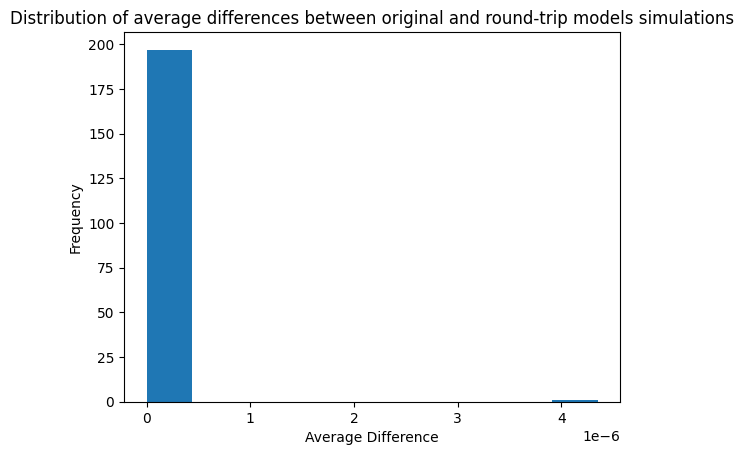

In [6]:
diffs = []
for model, (result, new_result) in results.items():
    average_diff = np.mean(abs(result - new_result))   
    diffs.append(average_diff)
    if average_diff > 0:
        print(model, average_diff)

plt.hist(diffs)
plt.title("Distribution of average differences between original and round-trip models simulations")
plt.xlabel("Average Difference")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(f"Across {len(results)} models tested")
print(f"There are {sum(diff == 0 for diff in diffs)} models that are exactly same before and after round trip")

Across 198 models tested
There are 197 models that are exactly same before and after round trip


The difference comes from 10 rules being different.   
All are purely associativity changes in AND chains (right-associative → left-associative). E.g., `(S_13 AND (S_35 AND S_116))` has been converted to `((S_13 AND S_35) AND S_116)`  
AND is associative so all should be logically equivalent.